(20,)
i    18
j    19
dtype: int64


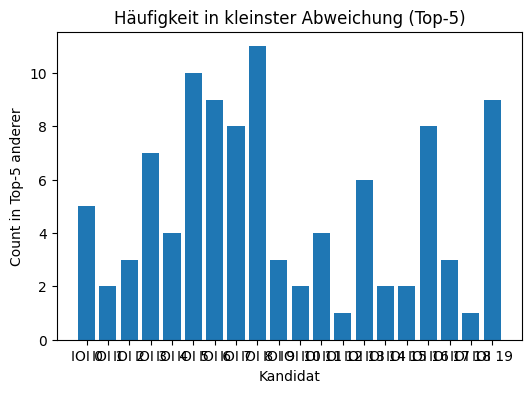

    index       ioi  K_int  base_candidate  pair_with     ratio  proximity  \
0       0  1.790103      1        1.790103         11  1.003218   0.999897   
1       0  1.790103      1        1.790103         13  1.007073   0.999501   
2       0  1.790103      1        1.790103          7  3.005770   0.998293   
3       0  1.790103      1        1.790103          2  1.032873   0.988848   
4       0  1.790103      1        1.790103         19  2.978752   0.977383   
..    ...       ...    ...             ...        ...       ...        ...   
95     19  0.600958      1        0.600958         13  2.999822   0.999998   
96     19  0.600958      1        0.600958          6  1.000858   0.999993   
97     19  0.600958      1        0.600958          8  1.997851   0.999871   
98     19  0.600958      1        0.600958          7  1.009070   0.999177   
99     19  0.600958      1        0.600958          5  2.012282   0.995764   

   peak_label  
0         1/1  
1         1/1  
2         3/1  

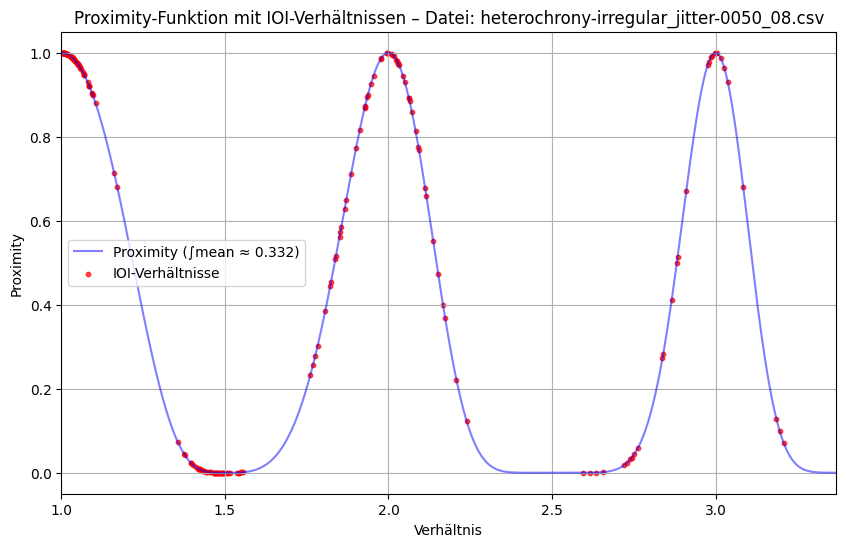

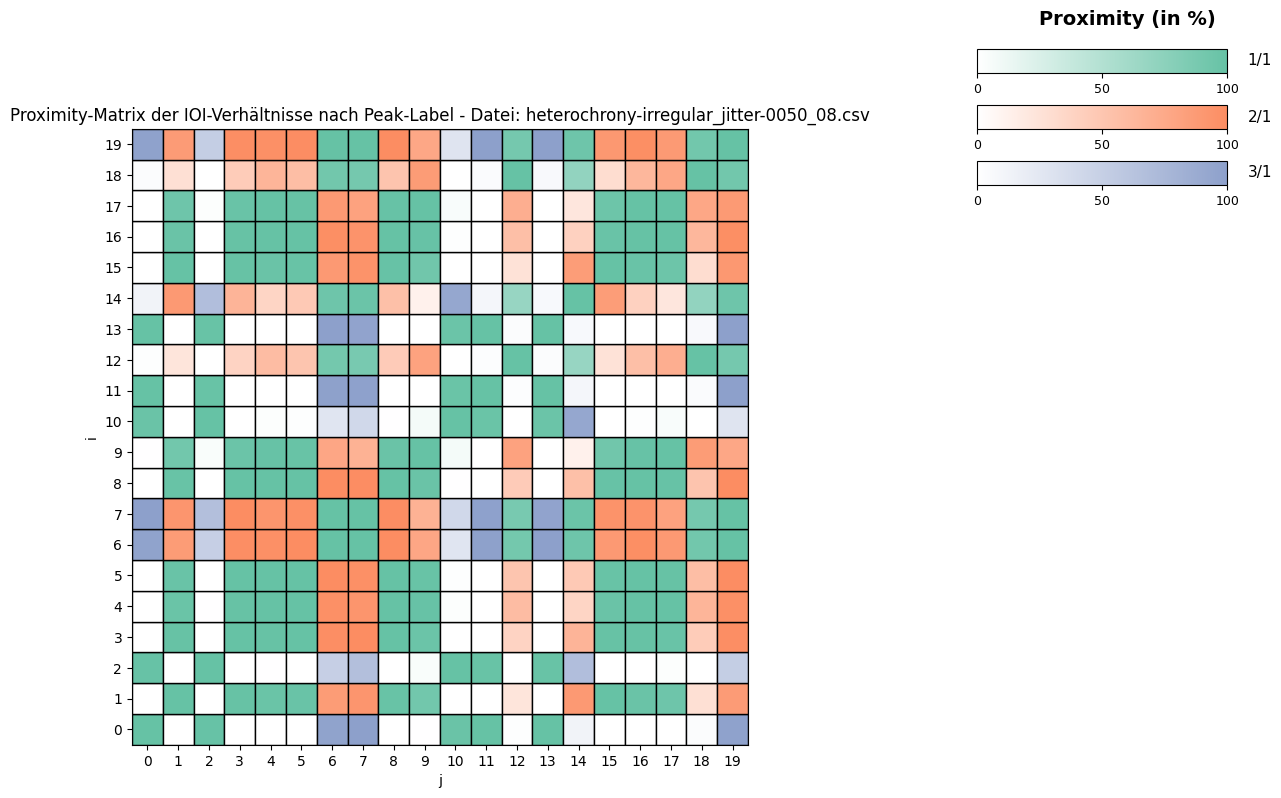

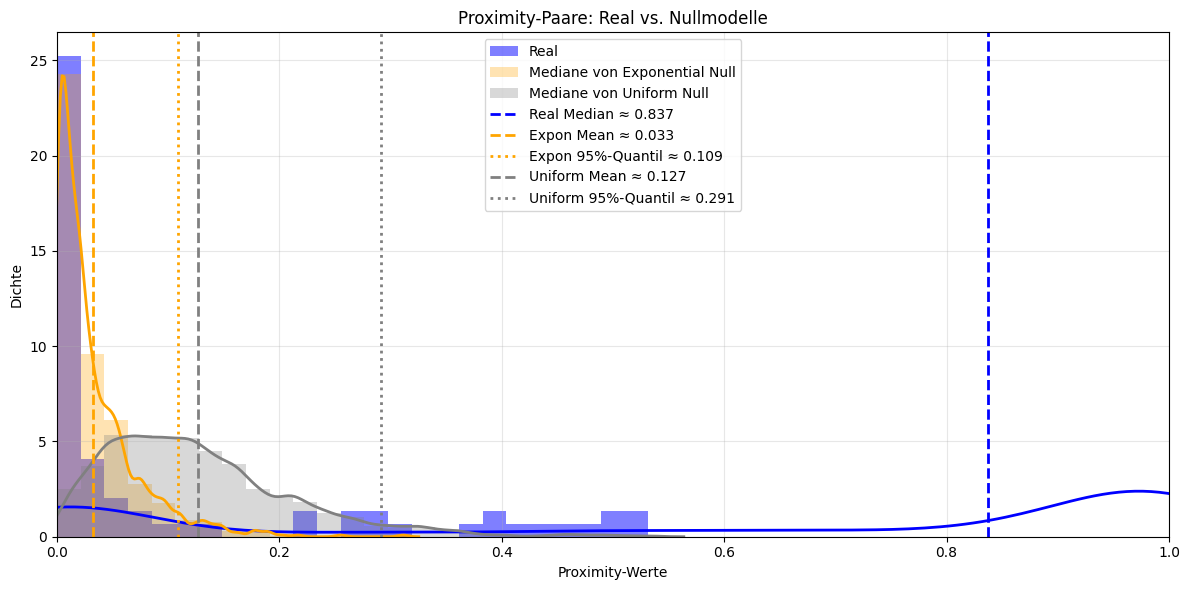


=== Ergebnisse ===
median_real: 0.8370
median_expon: 0.0329
std_expon: 0.0372
zscore_expon: 21.6064
pval_expon: 0.0010
median_uniform: 0.1273
std_uniform: 0.0851
zscore_uniform: 8.3375
pval_uniform: 0.0010
quant95_expon: 0.1087
quant95_uniform: 0.2915


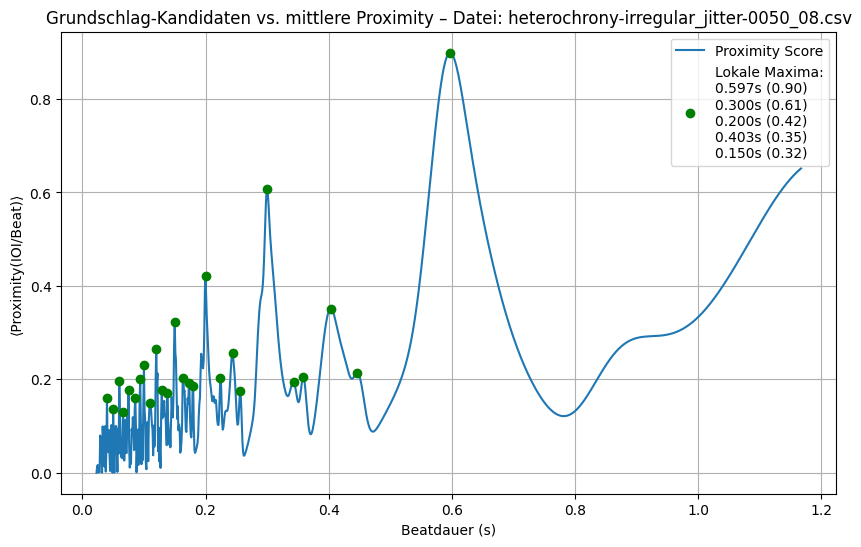

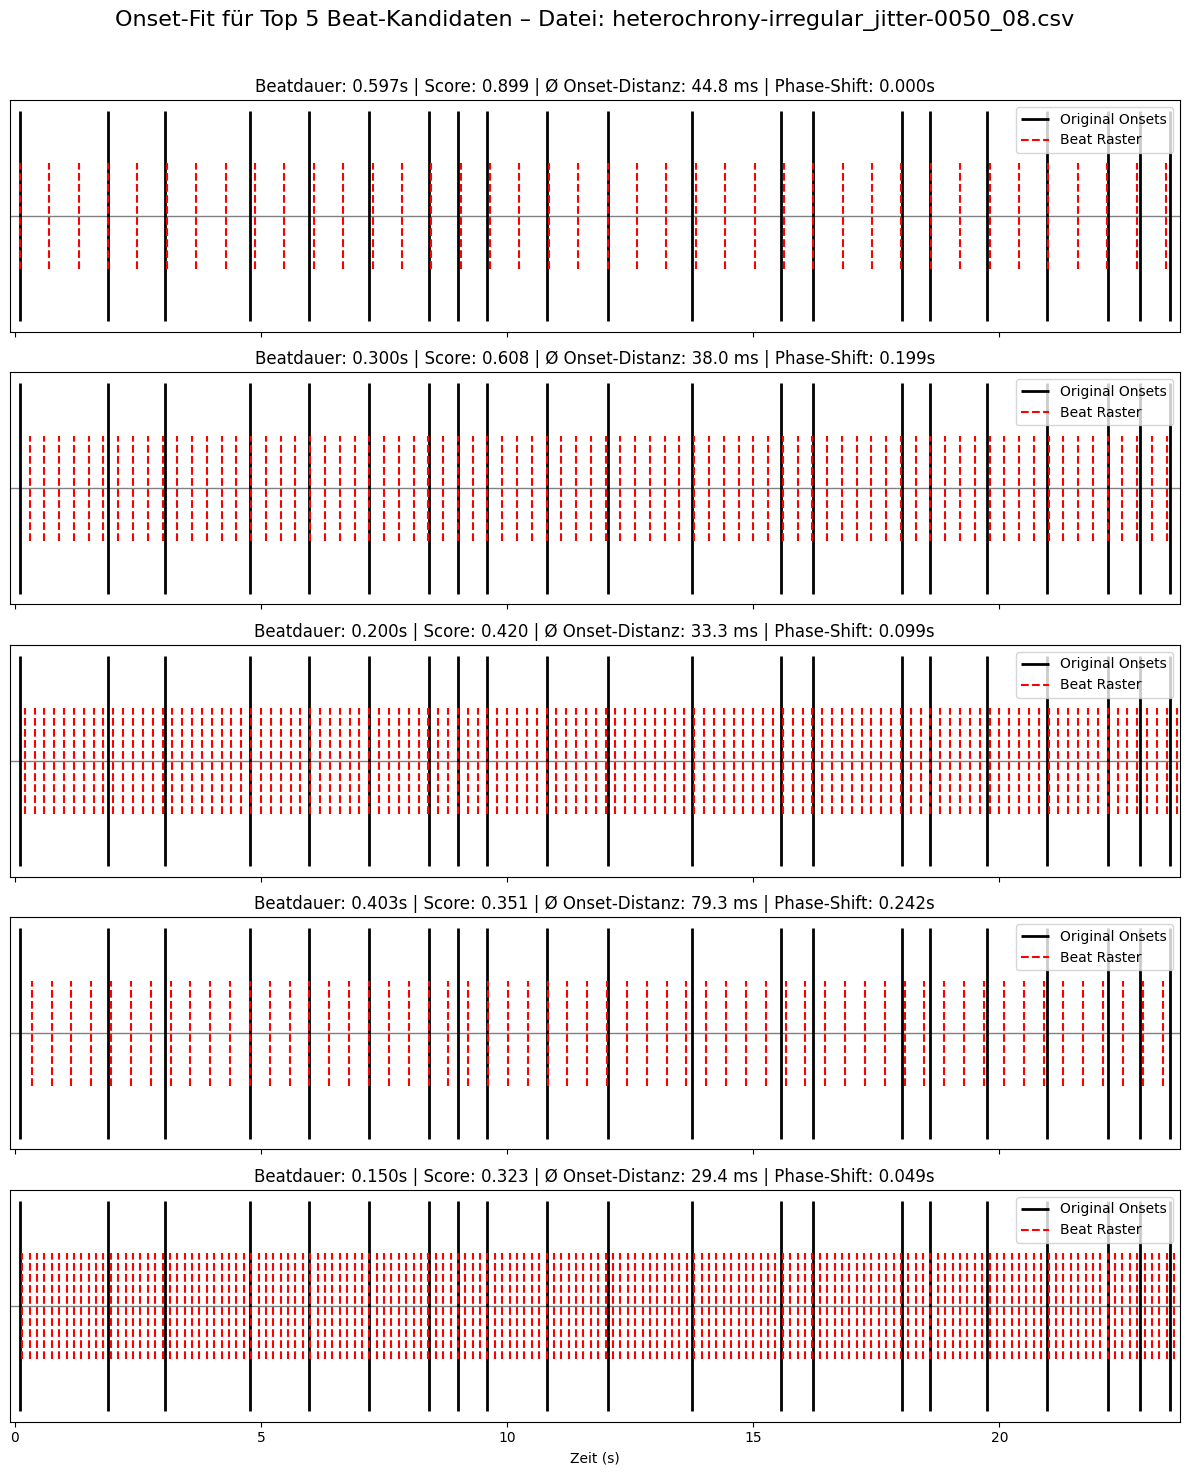

In [1]:
# doof
# === 0) new Initialisierung ===

# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=8.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Basis-IOI aus Paaren bestimmen (LCM-Methode)
# =============================
def best_fit_ioi_from_pairs(iois, df_pairs, threshold):
    valid_pairs = df_pairs[df_pairs["proximity"] > threshold]
    fractions_list = []
    for label in valid_pairs["peak_label"]:
        if label != "Keine Proximity":
            num, den = map(int, label.split("/"))
            fractions_list.append(Fraction(num, den))

    if not fractions_list:
        return None

    denominators = [frac.denominator for frac in fractions_list]
    lcm_den = np.lcm.reduce(denominators)

    # Vielfachfaktor pro IOI bestimmen
    k_values = [None] * len(iois)
    for idx in range(len(iois)):
        factors = []
        for _, row in valid_pairs.iterrows():
            if row["peak_label"] == "Keine Proximity":
                continue
            num, den = map(int, row["peak_label"].split("/"))
            frac = Fraction(num, den)
            num_scaled = frac.numerator * (lcm_den // frac.denominator)
            if row["i"] == idx:
                factors.append(num_scaled)
            elif row["j"] == idx:
                factors.append(num_scaled)
        if factors:
            k_values[idx] = min(factors)

    if any(k is None for k in k_values):
        print("Warnung: Nicht für alle IOIs ein Faktor gefunden.")
        return None

    base_ioi = np.mean([iois[i] / k_values[i] for i in range(len(iois))])
    return base_ioi

# =============================
# 4) Parameter, Daten laden & Pairs bauen
# =============================
params = dict(
    sharpness_base=1.0,
    sharpness_growth=1.498051,
    decay=0.0,
    max_freq=1,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01

filename = "heterochrony-irregular_jitter-0050_08.csv"
base_dir = Path("../data/theoretical_sequences/baseIOI-0.60/20beats/")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)

# Nur gültige IOIs verwenden
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# Pairs sofort neu berechnen – kein alter Cache!
df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)

# =============================
# compute_ioi_positions_fixed – jetzt mit Auto-Check
# =============================
def compute_ioi_positions_fixed(iois, df_pairs, threshold=0.01, verbose=False):
    """
    Aus Paar-DF -> IOI-Positions-DF mit konsistenter Netzwerk-Skalierung.
    Immer 5 Zeilen pro IOI (mit evtl. 0-Abweichung).
    Außerdem am Ende: Barplot mit Counts pro Kandidat.
    """

    # --- Sicherheitscheck ---
    max_index_in_pairs = max(df_pairs["i"].max(), df_pairs["j"].max())
    if max_index_in_pairs >= len(iois):
        print("⚠️ df_pairs passt nicht zu iois – baue neu...")
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params, threshold=threshold)

    n = len(iois)

    # --- 1) Kantenliste ---
    edges = []
    for r in df_pairs.itertuples():
        if getattr(r, "proximity", 0) <= threshold:
            continue
        label = getattr(r, "peak_label", "")
        if not label or label == "Keine Proximity":
            continue
        try:
            p, q = map(int, label.split("/"))
        except Exception:
            continue
        if r.ioi_i >= r.ioi_j:
            u, v, frac = int(r.i), int(r.j), Fraction(p, q)
        else:
            u, v, frac = int(r.j), int(r.i), Fraction(p, q)
        edges.append((u, v, frac))

    # --- 2) BFS / Propagation ---
    K_rel = [None] * n
    seed = int(np.argmax(iois))
    K_rel[seed] = Fraction(1, 1)
    changed = True
    for _ in range(10 * n):
        if not changed:
            break
        changed = False
        for u, v, frac in edges:
            if K_rel[u] is not None and K_rel[v] is None:
                K_rel[v] = K_rel[u] * Fraction(frac.denominator, frac.numerator)
                changed = True
            elif K_rel[v] is not None and K_rel[u] is None:
                K_rel[u] = K_rel[v] * frac
                changed = True
    for idx, val in enumerate(K_rel):
        if val is None:
            K_rel[idx] = Fraction(1, 1)

    # --- 3) Basistakt ---
    K_rel_float = np.array([float(k) for k in K_rel])
    base_candidates = np.array(iois) / K_rel_float
    t0 = float(np.median(base_candidates))
    if t0 <= 0:
        raise RuntimeError("Ungültiger t0")

    # --- 4) Ganzzahlige K_int ---
    K_int = np.rint(np.array(iois) / t0).astype(int)
    K_int[K_int < 1] = 1
    g = int(reduce(gcd, K_int.tolist()))
    if g > 1:
        K_int //= g

    # --- 5) DataFrame (Top-5 Paare) ---
    rows = []
    for i in range(n):
        pairs_i = df_pairs[(df_pairs["i"] == i) | (df_pairs["j"] == i)]
        pairs_i = pairs_i.sort_values(by="proximity", ascending=False)
        while len(pairs_i) < 5:
            pairs_i = pd.concat([pairs_i, pd.DataFrame([{
                "i": i, "j": None, "ioi_i": iois[i], "ioi_j": None,
                "ratio": None, "proximity": 0.0, "peak_label": "Keine Abweichung"
            }])], ignore_index=True)
        top5 = pairs_i.head(5)
        for _, r in top5.iterrows():
            rows.append({
                "index": i,
                "ioi": iois[i],
                "K_int": int(K_int[i]),
                "base_candidate": float(iois[i] / K_int[i]),
                "pair_with": r["j"] if r["i"] == i else r["i"],
                "ratio": r["ratio"],
                "proximity": r["proximity"],
                "peak_label": r["peak_label"]
            })

    df_ioi_positions = pd.DataFrame(rows)

    # --- 6) Barplot ---
    counts = df_ioi_positions["pair_with"].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    plt.bar(range(len(counts)), counts.values, tick_label=[f"IOI {i}" for i in counts.index])
    plt.xlabel("Kandidat")
    plt.ylabel("Count in Top-5 anderer")
    plt.title("Häufigkeit in kleinster Abweichung (Top-5)")
    plt.show()

    if verbose:
        print("t0:", t0)
        print("K_int:", K_int.tolist())

    return df_ioi_positions, t0

# =============================
# Anwendung auf Daten
# =============================
print(iois.shape)
print(df_pairs[['i', 'j']].max())

df_ioi_positions, t0 = compute_ioi_positions_fixed(iois, df_pairs, threshold=PAIR_THRESHOLD)

if df_ioi_positions is not None:
    print(df_ioi_positions)
    print("\nGemittelter Basis-IOI:", df_ioi_positions["base_candidate"].mean())
else:
    print("Keine gültigen Verhältnisse gefunden.")

# === 1) Proximity-Funktion + Punkte ===
plt.figure(figsize=(10, 6))

# Dynamische Grenzen aus den Daten bestimmen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)  # kleiner Puffer nach unten
x_max = df_pairs["ratio"].max() * 1.05            # Puffer nach oben

# Blaue Kurve über den ganzen Plotbereich
x_range = np.linspace(x_min, x_max, 2000)
y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])

# Mittelwert für diesen Bereich
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

# Plotten
plt.plot(
    x_range,
    y_curve,
    label=f"Proximity (∫mean ≈ {mean_prox:.3f})",
    alpha=0.5,
    color="blue"
)
plt.scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, 
            s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")

plt.title(f"Proximity-Funktion mit IOI-Verhältnissen – Datei: {filename}")
plt.xlabel("Verhältnis")
plt.ylabel("Proximity")
plt.xlim(x_min, x_max)
plt.legend()
plt.grid(True)
plt.show()

# === 2) Recurrence-Plot (Peak-Label-Farbskalen) ===

# === all_pairs_df erstellen ===
records = []
n = len(iois)
for i in range(n):
    for j in range(n):
        ratio = max(iois[i], iois[j]) / min(iois[i], iois[j])
        prox_val = proximity_max_freq([ratio], **params)[0]
        if prox_val > PAIR_THRESHOLD:
            frac = Fraction(ratio).limit_denominator(params["max_freq"])
            peak_label = f"{frac.numerator}/{frac.denominator}"
        else:
            peak_label = "Keine Proximity"
        records.append({
            "i": i,
            "j": j,
            "ioi_i": iois[i],
            "ioi_j": iois[j],
            "ratio": ratio,
            "prox_value": prox_val,
            "peak_label": peak_label
        })
all_pairs_df = pd.DataFrame.from_records(records)

# === Plot vorbereiten ===
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")

unique_labels = sorted(set(all_pairs_df["peak_label"]))
palette = sns.color_palette("Set2", len(unique_labels))
label_to_cmap = {}
for label, base_color in zip(unique_labels, palette):
    white_rgb = (1, 1, 1)
    cmap_colors = [white_rgb, base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# === Plot zeichnen ===
fig, ax = plt.subplots(figsize=(10, 8))
for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]
    color = cmap(val / 100)  # Wert zwischen 0 und 1
    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    val_float = float(val[0])     # explizit erstes Element wählen # von ndarray zu Skalar
    #ax.text(j + 0.5, i + 0.5, f"{int(round(val_float))}", ha='center', va='center', fontsize=8) # ausschalten, wenn lange sequenz

# Achsen von 0 aufsteigend
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect('equal')
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(range(n))
ax.set_yticklabels(range(n))
ax.set_xlabel("j")
ax.set_ylabel("i")
ax.set_title(f"Proximity-Matrix der IOI-Verhältnisse nach Peak-Label - Datei: {filename}")

# Nur Verhältnisse mit Proximity > 0 anzeigen
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]

# Position für die Legende rechts neben dem Plot
legend_x_start = 1.05
legend_y_start = 0.95
cbar_height = 0.03
spacing = 0.04

# Überschrift für alle Skalen
fig.text(legend_x_start + 0.15, legend_y_start + 0.06, "Proximity (in %)", 
         ha="center", fontsize=14, fontweight="bold")

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)

    y_pos = legend_y_start - idx * (cbar_height + spacing)

    # Größerer horizontaler Farbbalken
    cbar_ax = fig.add_axes([legend_x_start, y_pos, 0.25, cbar_height])  
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                      cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)

    # Verhältnis rechts vom Balken
    fig.text(legend_x_start + 0.27, y_pos + cbar_height / 2, label,
             va="center", fontsize=11)

plt.show()

# === 3) Kombiniertes Histogramm mit Anteilen + 95%-Quantil ===
def analyze_single_sequence(iois, params, num_sequences=1000, seed=42, bins=50, plot_kde=True):
    """
    Analysiert eine einzelne IOI-Sequenz gegen zwei Nullmodelle (Exponential, Uniform)
    und erstellt Histogramm mit Mean, 95%-Quantilen, Z-Score und p-Wert.
    
    Rückgabe: dict mit realen Proximity-Paaren, Nullmodellen und Statistik.
    """
    rng = np.random.default_rng(seed)
    sequence_length = len(iois)
    max_ioi = float(np.max(iois))
    mean_ioi = float(np.mean(iois))
    
    # -----------------------------
    # Reale Proximity-Paare
    # -----------------------------
    ratios_real = np.array([[max(iois[i], iois[j])/min(iois[i], iois[j]) 
                             for j in range(sequence_length)] for i in range(sequence_length)])
    prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
    triu_idx = np.triu_indices_from(prox_mat_real, k=1)
    proximity_real = prox_mat_real[triu_idx]
    median_real = np.median(proximity_real)
    
    # -----------------------------
    # Nullmodell: Exponential
    # -----------------------------
    medians_expon = []
    proximity_expon_all = []
    for _ in range(num_sequences):
        sim_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
        ratios = np.array([[max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat, _, _ = proximity_max_freq(ratios, **params)
        vals = prox_mat[triu_idx]
        proximity_expon_all.append(vals)
        medians_expon.append(np.median(vals))
    proximity_expon_all = np.concatenate(proximity_expon_all)
    median_expon = np.mean(medians_expon)
    std_expon = np.std(medians_expon, ddof=1)
    zscore_expon = (median_real - median_expon) / (std_expon + 1e-12)
    pval_expon = (np.sum(np.array(medians_expon) >= median_real) + 1) / (num_sequences + 1)
    quant95_expon = np.percentile(medians_expon, 95)
    
    # -----------------------------
    # Nullmodell: Uniform
    # -----------------------------
    medians_uniform = []
    proximity_uniform_all = []
    for _ in range(num_sequences):
        sim_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
        ratios = np.array([[max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat, _, _ = proximity_max_freq(ratios, **params)
        vals = prox_mat[triu_idx]
        proximity_uniform_all.append(vals)
        medians_uniform.append(np.median(vals))
    proximity_uniform_all = np.concatenate(proximity_uniform_all)
    median_uniform = np.mean(medians_uniform)
    std_uniform = np.std(medians_uniform, ddof=1)
    zscore_uniform = (median_real - median_uniform) / std_uniform if std_uniform > 0 else np.nan
    pval_uniform = (np.sum(np.array(medians_uniform) >= median_real) + 1) / (num_sequences + 1)
    quant95_uniform = np.percentile(medians_uniform, 95)
    
    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12,6))
    colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
    
    # Gemeinsamer Wertebereich über beide Nullmodelle
    all_nulls = np.concatenate([medians_expon, medians_uniform])
    bin_edges = np.linspace(np.min(all_nulls), np.max(all_nulls), bins+1)

    plt.hist(proximity_real, bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
    plt.hist(medians_expon, bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Mediane von Exponential Null")
    plt.hist(medians_uniform, bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Mediane von Uniform Null")
    
    if plot_kde:
        sns.kdeplot(proximity_real, bw_adjust=0.5, color=colors["Real"], linewidth=2)
        sns.kdeplot(medians_expon, bw_adjust=0.5, color=colors["Expon"], linewidth=2)
        sns.kdeplot(medians_uniform, bw_adjust=0.5, color=colors["Uniform"], linewidth=2)
    
    # Mittelwerte & 95%-Quantile
    plt.axvline(median_real, color=colors["Real"], linestyle="--", linewidth=2, label=f"Real Median ≈ {median_real:.3f}")
    plt.axvline(median_expon, color=colors["Expon"], linestyle="--", linewidth=2, label=f"Expon Mean ≈ {median_expon:.3f}")
    plt.axvline(quant95_expon, color=colors["Expon"], linestyle=":", linewidth=2, label=f"Expon 95%-Quantil ≈ {quant95_expon:.3f}")
    plt.axvline(median_uniform, color=colors["Uniform"], linestyle="--", linewidth=2, label=f"Uniform Mean ≈ {median_uniform:.3f}")
    plt.axvline(quant95_uniform, color=colors["Uniform"], linestyle=":", linewidth=2, label=f"Uniform 95%-Quantil ≈ {quant95_uniform:.3f}")
    
    plt.xlabel("Proximity-Werte")
    plt.ylabel("Dichte")
    plt.title("Proximity-Paare: Real vs. Nullmodelle")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()
    
    # -----------------------------
    # Ergebnisse zurückgeben
    # -----------------------------
    results = {
        "median_real": median_real,
        "median_expon": median_expon,
        "std_expon": std_expon,
        "zscore_expon": zscore_expon,
        "pval_expon": pval_expon,
        "median_uniform": median_uniform,
        "std_uniform": std_uniform,
        "zscore_uniform": zscore_uniform,
        "pval_uniform": pval_uniform,
        "quant95_expon": quant95_expon,
        "quant95_uniform": quant95_uniform,
    }
    print("\n=== Ergebnisse ===")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")
        
    return {
        "proximity_real": proximity_real,
        "proximity_expon_all": proximity_expon_all,
        "proximity_uniform_all": proximity_uniform_all,
        "results": results
    }

results = analyze_single_sequence(iois, params, num_sequences=1000, seed=42, bins=25, plot_kde=True)

# === 4) Beatfinding via Kandidaten und lokalen Maxima ===

# =============================
# 2) Hilfsfunktionen
# =============================
def round_to_resolution(x, resolution):
    return round(x / resolution) * resolution

def generate_beat_candidates_from_iois(iois, resolution=0.001, max_denominator=24):
    if len(iois) == 0:
        return []

    max_ioi = float(np.max(iois))
    min_ioi = float(np.min(iois)) / max_denominator  # dynamisches min_ioi

    raster = np.arange(min_ioi, max_ioi + resolution/2, resolution)
    candidates = set(round_to_resolution(val, resolution) for val in raster)

    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(round_to_resolution(beat, resolution))

    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(round_to_resolution(val, resolution))

    # === Filter: Kandidaten müssen mindestens so viele Beats abdecken wie IOIs existieren ===
    duration = float(np.sum(iois))
    n_iois = len(iois)
    filtered_candidates = []
    for beat in sorted(candidates):
        if beat <= 0:  # ❌ Filter für 0 und negative Beats
            continue
        n_beats = int(duration // beat)
        if n_beats >= n_iois:
            filtered_candidates.append(beat)

    return filtered_candidates

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

# =============================
# 7) Beat-Kandidaten
# =============================
beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# === 4) Beat-Kandidaten & Score ===
plt.figure(figsize=(10, 6))
plt.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    plt.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5]
plt.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
plt.title(f"Grundschlag-Kandidaten vs. mittlere Proximity – Datei: {filename}")
plt.xlabel("Beatdauer (s)")
plt.ylabel("⟨Proximity(IOI/Beat)⟩")
plt.legend()
plt.grid(True)
plt.show()

# =============================
# 8) Top-5 Onset-Fit
# =============================
def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

n_top = len(local_maxima_top5)
if n_top > 0:
    fig2, axes2 = plt.subplots(n_top, 1, figsize=(12, 3 * n_top), sharex=True)
    fig2.suptitle(f"Onset-Fit für Top {n_top} Beat-Kandidaten – Datei: {filename}", fontsize=16)
    if n_top == 1:
        axes2 = [axes2]
    for idx, (beat, score) in enumerate(local_maxima_top5):
        ax = axes2[idx]
        best_shift = find_best_phase_shift(onsets, beat)
        stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)
        ax.axhline(0, color='gray', linewidth=1)
        ax.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets')
        ax.vlines(stats["beat_times"], -0.1, 0.1, color='red', linestyle='--', label='Beat Raster')
        title = (
        f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | "
        f"Ø Onset-Distanz: {stats['mean_onset_dist']*1000:.1f} ms | "
        f"Phase-Shift: {best_shift:.3f}s"
        )
        ax.set_title(title)
        ax.set_yticks([])
        ax.set_xlim(onsets[0] - 0.2, onsets[-1] + 0.2)
        ax.legend(loc='upper right')
    plt.xlabel("Zeit (s)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("\nKeine lokalen Maxima gefunden — überspringe Onset-Fit Visualisierung.")

In [ ]:
# ausreichende Initialisierung ohne Plots
# === 0) new Initialisierung ===

# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=1.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Basis-IOI aus Paaren bestimmen (LCM-Methode)
# =============================
def best_fit_ioi_from_pairs(iois, df_pairs, threshold):
    valid_pairs = df_pairs[df_pairs["proximity"] > threshold]
    fractions_list = []
    for label in valid_pairs["peak_label"]:
        if label != "Keine Proximity":
            num, den = map(int, label.split("/"))
            fractions_list.append(Fraction(num, den))

    if not fractions_list:
        return None

    denominators = [frac.denominator for frac in fractions_list]
    lcm_den = np.lcm.reduce(denominators)

    # Vielfachfaktor pro IOI bestimmen
    k_values = [None] * len(iois)
    for idx in range(len(iois)):
        factors = []
        for _, row in valid_pairs.iterrows():
            if row["peak_label"] == "Keine Proximity":
                continue
            num, den = map(int, row["peak_label"].split("/"))
            frac = Fraction(num, den)
            num_scaled = frac.numerator * (lcm_den // frac.denominator)
            if row["i"] == idx:
                factors.append(num_scaled)
            elif row["j"] == idx:
                factors.append(num_scaled)
        if factors:
            k_values[idx] = min(factors)

    if any(k is None for k in k_values):
        print("Warnung: Nicht für alle IOIs ein Faktor gefunden.")
        return None

    base_ioi = np.mean([iois[i] / k_values[i] for i in range(len(iois))])
    return base_ioi

# =============================
# 4) Parameter, Daten laden & Pairs bauen
# =============================
params = dict(
    sharpness_base=1.0,
    sharpness_growth=1.498051,
    decay=0.0,
    max_freq=1,
    weight_exponent=1.967722,
    freq_sharpness_exp=4.0,
    norm_x=1.0,
    output_max=1.0
)

PAIR_THRESHOLD = 0.01

filename = "heterochrony-1-2_jitter-0050_07.csv"
base_dir = Path("../testing for bayesian/")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)

# Nur gültige IOIs verwenden
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# Pairs sofort neu berechnen – kein alter Cache!
df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)

# =============================
# Anwendung auf Daten
# =============================

# Dynamische Grenzen aus den Daten bestimmen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)  # kleiner Puffer nach unten
x_max = df_pairs["ratio"].max() * 1.05            # Puffer nach oben

# Blaue Kurve über den ganzen Plotbereich
x_range = np.linspace(x_min, x_max, 2000)
y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])

# Mittelwert für diesen Bereich
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

# === 2) Recurrence-Plot (Peak-Label-Farbskalen) ===

# === all_pairs_df erstellen ===
records = []
n = len(iois)
for i in range(n):
    for j in range(n):
        ratio = max(iois[i], iois[j]) / min(iois[i], iois[j])
        prox_val = proximity_max_freq([ratio], **params)[0]
        if prox_val > PAIR_THRESHOLD:
            frac = Fraction(ratio).limit_denominator(params["max_freq"])
            peak_label = f"{frac.numerator}/{frac.denominator}"
        else:
            peak_label = "Keine Proximity"
        records.append({
            "i": i,
            "j": j,
            "ioi_i": iois[i],
            "ioi_j": iois[j],
            "ratio": ratio,
            "prox_value": prox_val,
            "peak_label": peak_label
        })
all_pairs_df = pd.DataFrame.from_records(records)

# === Plot vorbereiten ===
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")

unique_labels = sorted(set(all_pairs_df["peak_label"]))

# --- Fixe Farbzuordnung für kleine Brüche ---
tab10 = plt.cm.tab10.colors  

fixed_colors = {
    "1/1": tab10[0],  # blau
    "2/1": tab10[1],  # orange
    "3/1": tab10[2],  # grün
    "4/1": tab10[3],  # rot
    "5/1": tab10[4],  # lila
    "1/2": tab10[5],  # braun
    "3/2": tab10[6],  # pink
    "5/2": tab10[7],  # grau
    "1/3": tab10[8],  # olivgrün
    "2/3": tab10[9],  # hellblau
    "4/3": (0.5, 0.0, 0.5)  # extra-farbe (dunkelviolett), da tab10 nur 10 hat
}

label_to_cmap = {}

# Zuerst feste Farben vergeben
for label, color in fixed_colors.items():
    if label in unique_labels:
        cmap_colors = [(1,1,1), plt.cm.colors.to_rgb(color)]
        label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# Rest wie vorher aus Palette
remaining_labels = [lab for lab in unique_labels if lab not in label_to_cmap]
palette = sns.color_palette("Set2", len(remaining_labels))
for label, base_color in zip(remaining_labels, palette):
    cmap_colors = [(1,1,1), base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# === 3) Kombiniertes Histogramm mit Anteilen + 95%-Quantil ===
def analyze_single_sequence(iois, params, num_sequences=1000, seed=42, bins=50, plot=True):
    """
    Analysiert eine einzelne IOI-Sequenz gegen zwei Nullmodelle (Exponential, Uniform)
    und erstellt Histogramm mit Mean, 95%-Quantilen, Z-Score und p-Wert.
    
    Rückgabe: dict mit realen Proximity-Paaren, Nullmodellen und Statistik.
    """
    rng = np.random.default_rng(seed)
    sequence_length = len(iois)
    max_ioi = float(np.max(iois))
    mean_ioi = float(np.mean(iois))
    
    # -----------------------------
    # Reale Proximity-Paare
    # -----------------------------
    ratios_real = np.array([[max(iois[i], iois[j])/min(iois[i], iois[j]) 
                             for j in range(sequence_length)] for i in range(sequence_length)])
    prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
    triu_idx = np.triu_indices_from(prox_mat_real, k=1)
    proximity_real = prox_mat_real[triu_idx]
    median_real = np.median(proximity_real)
    
    # -----------------------------
    # Nullmodell: Exponential
    # -----------------------------
    medians_expon = []
    proximity_expon_all = []
    for _ in range(num_sequences):
        sim_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
        ratios = np.array([[max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat, _, _ = proximity_max_freq(ratios, **params)
        vals = prox_mat[triu_idx]
        proximity_expon_all.append(vals)
        medians_expon.append(np.median(vals))
    proximity_expon_all = np.concatenate(proximity_expon_all)
    median_expon = np.mean(medians_expon)
    std_expon = np.std(medians_expon, ddof=1)
    zscore_expon = (median_real - median_expon) / (std_expon + 1e-12)
    pval_expon = (np.sum(np.array(medians_expon) >= median_real) + 1) / (num_sequences + 1)
    quant95_expon = np.percentile(medians_expon, 95)
    
    # -----------------------------
    # Nullmodell: Uniform
    # -----------------------------
    medians_uniform = []
    proximity_uniform_all = []
    for _ in range(num_sequences):
        sim_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
        ratios = np.array([[max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat, _, _ = proximity_max_freq(ratios, **params)
        vals = prox_mat[triu_idx]
        proximity_uniform_all.append(vals)
        medians_uniform.append(np.median(vals))
    proximity_uniform_all = np.concatenate(proximity_uniform_all)
    median_uniform = np.mean(medians_uniform)
    std_uniform = np.std(medians_uniform, ddof=1)
    zscore_uniform = (median_real - median_uniform) / std_uniform if std_uniform > 0 else np.nan
    pval_uniform = (np.sum(np.array(medians_uniform) >= median_real) + 1) / (num_sequences + 1)
    quant95_uniform = np.percentile(medians_uniform, 95)
    
    # -----------------------------
    # Plot
    # -----------------------------
    if plot:
        plt.figure(figsize=(12,6))
        colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
        
        # Gemeinsamer Wertebereich über beide Nullmodelle
        all_nulls = np.concatenate([medians_expon, medians_uniform])
        bin_edges = np.linspace(np.min(all_nulls), np.max(all_nulls), bins+1)

        plt.hist(proximity_real, bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
        plt.hist(medians_expon, bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Mediane von Exponential Null")
        plt.hist(medians_uniform, bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Mediane von Uniform Null")
        
        sns.kdeplot(proximity_real, bw_adjust=0.5, color=colors["Real"], linewidth=2)
        sns.kdeplot(medians_expon, bw_adjust=0.5, color=colors["Expon"], linewidth=2)
        sns.kdeplot(medians_uniform, bw_adjust=0.5, color=colors["Uniform"], linewidth=2)
    
        # Mittelwerte & 95%-Quantile
        plt.axvline(median_real, color=colors["Real"], linestyle="--", linewidth=2, label=f"Real Median ≈ {median_real:.3f}")
        plt.axvline(median_expon, color=colors["Expon"], linestyle="--", linewidth=2, label=f"Expon Mean ≈ {median_expon:.3f}")
        plt.axvline(quant95_expon, color=colors["Expon"], linestyle=":", linewidth=2, label=f"Expon 95%-Quantil ≈ {quant95_expon:.3f}")
        plt.axvline(median_uniform, color=colors["Uniform"], linestyle="--", linewidth=2, label=f"Uniform Mean ≈ {median_uniform:.3f}")
        plt.axvline(quant95_uniform, color=colors["Uniform"], linestyle=":", linewidth=2, label=f"Uniform 95%-Quantil ≈ {quant95_uniform:.3f}")
        
        plt.xlabel("Proximity-Werte")
        plt.ylabel("Dichte")
        plt.title("Proximity-Paare: Real vs. Nullmodelle")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 1)
        plt.tight_layout()
        plt.show()
    
    # -----------------------------
    # Ergebnisse zurückgeben
    # -----------------------------
    results = {
        "median_real": median_real,
        "median_expon": median_expon,
        "std_expon": std_expon,
        "zscore_expon": zscore_expon,
        "pval_expon": pval_expon,
        "median_uniform": median_uniform,
        "std_uniform": std_uniform,
        "zscore_uniform": zscore_uniform,
        "pval_uniform": pval_uniform,
        "quant95_expon": quant95_expon,
        "quant95_uniform": quant95_uniform,
    }
    if plot:
        print("\n=== Ergebnisse ===")
        for k, v in results.items():
            print(f"{k}: {v:.4f}")
        
    return {
        "proximity_real": proximity_real,
        "proximity_expon_all": proximity_expon_all,
        "proximity_uniform_all": proximity_uniform_all,
        "results": results
    }

results = analyze_single_sequence(iois, params, num_sequences=1000, seed=42, bins=25, plot=False)

# === 4) Beatfinding via Kandidaten und lokalen Maxima ===

# =============================
# 2) Hilfsfunktionen
# =============================
def round_to_resolution(x, resolution):
    return round(x / resolution) * resolution

def generate_beat_candidates_from_iois(iois, resolution=0.001, max_denominator=24):
    if len(iois) == 0:
        return []

    max_ioi = float(np.max(iois))
    min_ioi = float(np.min(iois)) / max_denominator  # dynamisches min_ioi

    raster = np.arange(min_ioi, max_ioi + resolution/2, resolution)
    candidates = set(round_to_resolution(val, resolution) for val in raster)

    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(round_to_resolution(beat, resolution))

    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(round_to_resolution(val, resolution))

    # === Filter: Kandidaten müssen mindestens so viele Beats abdecken wie IOIs existieren ===
    duration = float(np.sum(iois))
    n_iois = len(iois)
    filtered_candidates = []
    for beat in sorted(candidates):
        if beat <= 0:  # ❌ Filter für 0 und negative Beats
            continue
        n_beats = int(duration // beat)
        if n_beats >= n_iois:
            filtered_candidates.append(beat)

    return filtered_candidates

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

# =============================
# 7) Beat-Kandidaten
# =============================
beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# =============================
# 8) Top-5 Onset-Fit
# =============================

def compute_beat_rmse(onsets, beat_period, resolution=0.001):
    """
    Berechnet den besten Phasen-Shift für die Beats, basierend auf RMSE.
    
    Parameters:
        onsets (array-like): Zeitpunkte der Onsets
        beat_period (float): vermutete Beatdauer
        resolution (float): Schrittweite für Phasen-Shift-Suche
    
    Returns:
        best_shift (float): Shift, der RMSE minimiert
        best_rmse (float): Minimaler RMSE-Wert
        best_beats (np.array): Beat-Zeiten mit optimalem Shift
    """
    onsets = np.array(onsets)
    first_onset = onsets[0]
    last_onset = onsets[-1]
    
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_rmse = float('inf')
    best_beats = None

    for shift in search_range:
        # Beat-Zeiten, einen Beat davor und einen danach erweitern
        start_beat = first_onset - beat_period + shift
        end_beat = last_onset + beat_period
        beats = np.arange(start_beat, end_beat + resolution, beat_period)

        # Für jeden Onset den nächsten Beat suchen
        nearest_beats = beats[np.argmin(np.abs(onsets[:, None] - beats[None, :]), axis=1)]

        # RMSE berechnen
        rmse = np.sqrt(((onsets - nearest_beats)**2).mean())

        if rmse < best_rmse:
            best_rmse = rmse
            best_shift = shift
            best_beats = beats

    return best_shift, best_rmse, best_beats


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_22425/1024695644.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


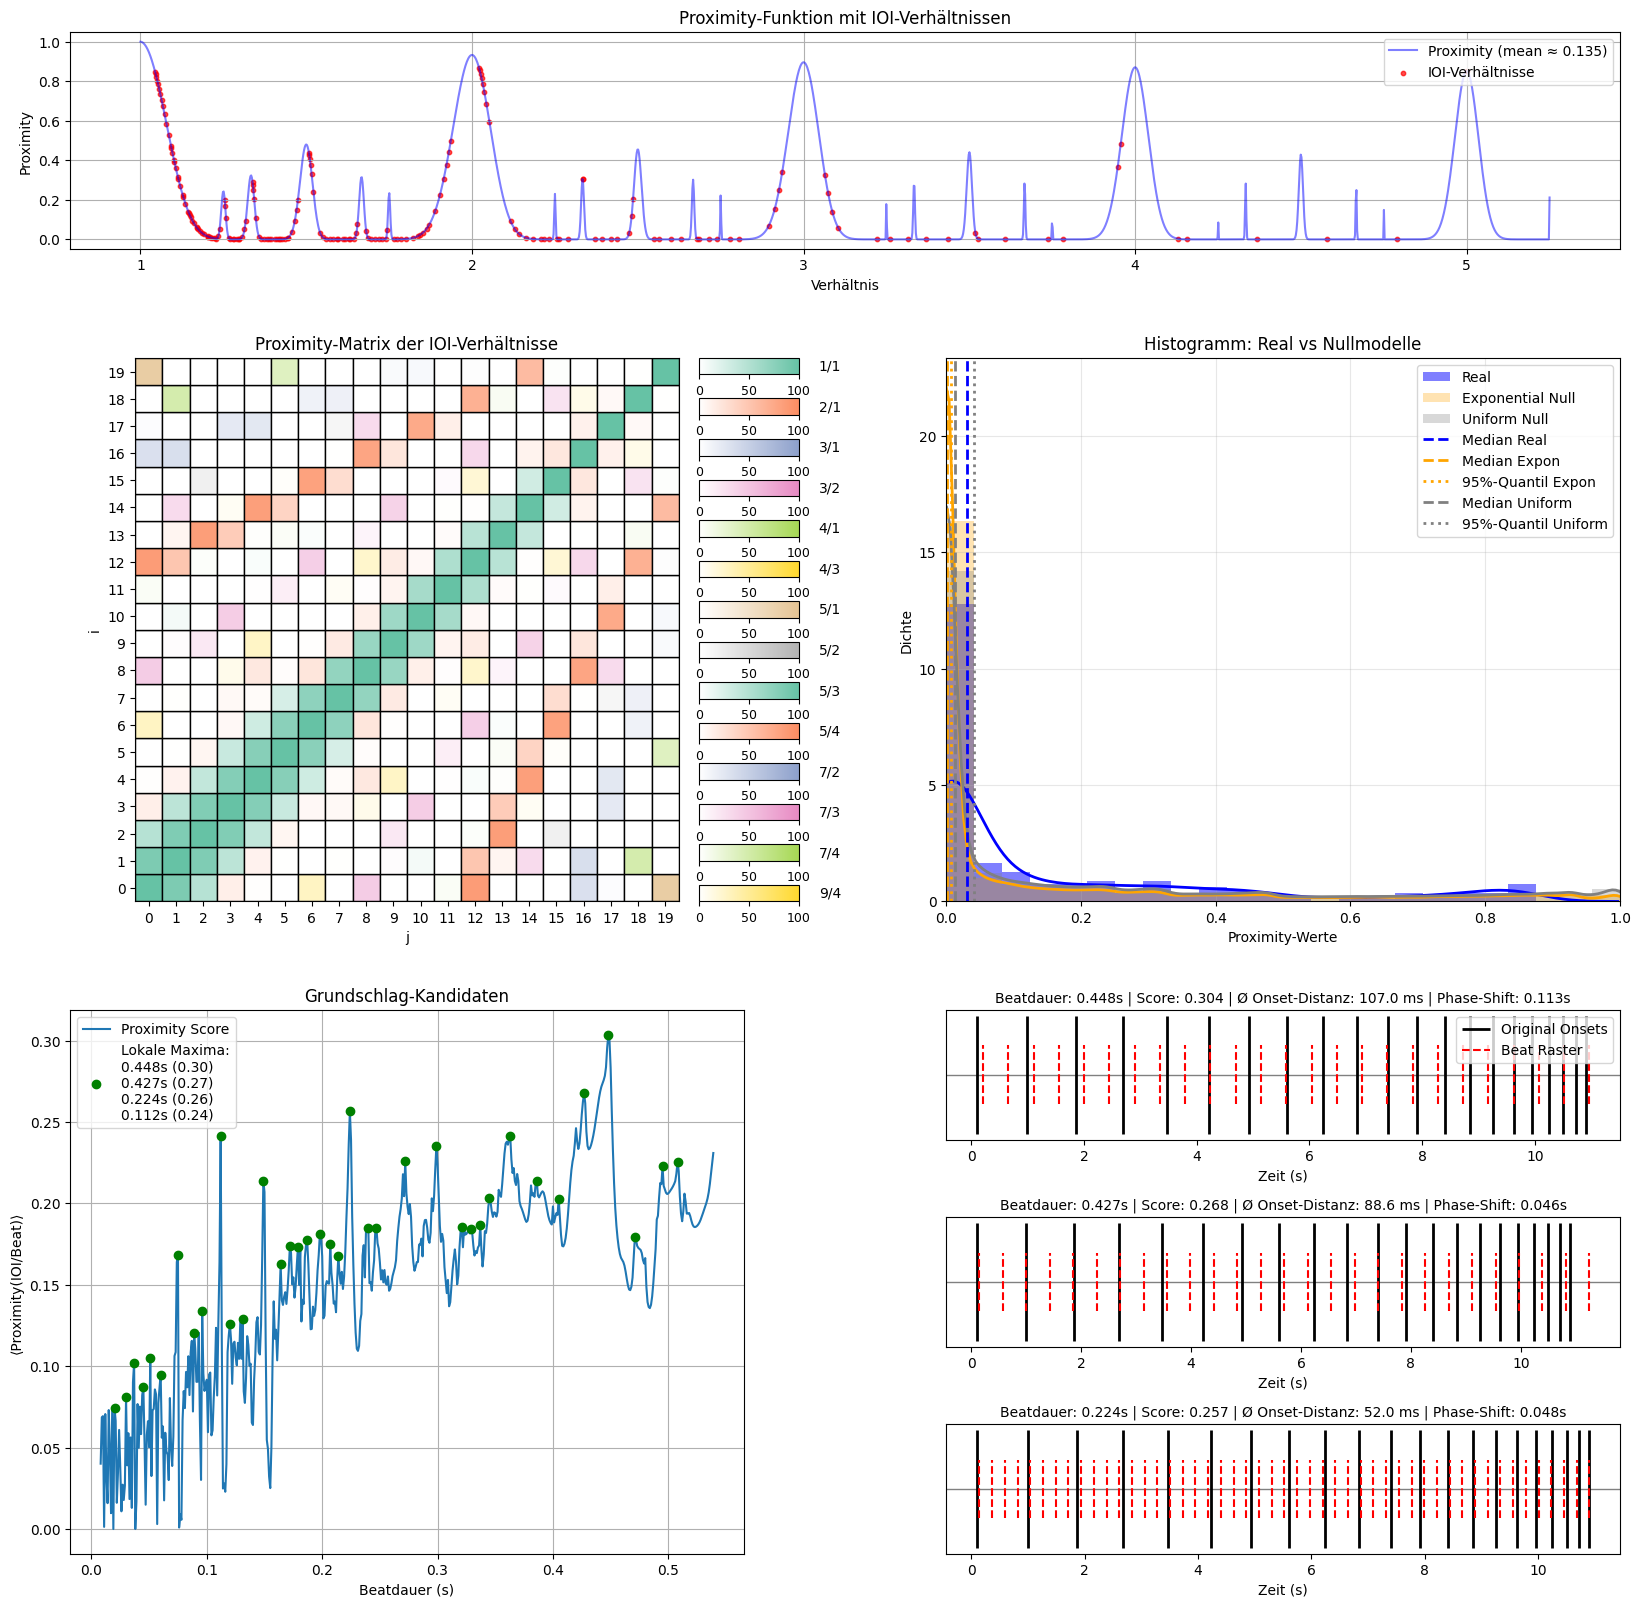

In [ ]:
# doof
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpecFromSubplotSpec

# -----------------------------
# 6x2 Grid vorbereiten
# -----------------------------
fig = plt.figure(figsize=(20, 24))
gs = gridspec.GridSpec(6, 2, figure=fig, width_ratios=[1,1], height_ratios=[1,1,1,1,1,1], hspace=0.5, wspace=0.3)
fig.suptitle(f"IOI-Analyse: {filename}", fontsize=22, fontweight='bold')

# =============================
# 1) Proximity-Funktion mit Punkten
# =============================
ax1 = fig.add_subplot(gs[0, :])
x_range = np.linspace(max(1.0, df_pairs["ratio"].min()*0.95), df_pairs["ratio"].max()*1.05, 2000)
y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])
mean_prox = np.mean(y_curve)
ax1.plot(x_range, y_curve, label=f"Proximity (mean ≈ {mean_prox:.3f})", alpha=0.5, color="blue")
ax1.scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
ax1.set_title("Proximity-Funktion mit IOI-Verhältnissen")
ax1.set_xlabel("Verhältnis")
ax1.set_ylabel("Proximity")
ax1.grid(True)
ax1.legend()

# =============================
# Recurrence-Plot + Histogramm rechts
# =============================
ax2 = fig.add_subplot(gs[1:3, 0])
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")
n = len(iois)

for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]
    color = cmap(val / 100)
    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
    ax2.add_patch(rect)

ax2.set_xlim(0, n)
ax2.set_ylim(0, n)
ax2.set_aspect('equal')
ax2.set_xticks(np.arange(n)+0.5)
ax2.set_yticks(np.arange(n)+0.5)
ax2.set_xticklabels(range(n))
ax2.set_yticklabels(range(n))
ax2.set_xlabel("j")
ax2.set_ylabel("i")
ax2.set_title("Proximity-Matrix der IOI-Verhältnisse")

# Farbskalen rechts innerhalb desselben Blocks
unique_labels = sorted(set(all_pairs_df["peak_label"]))
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]
pos = ax2.get_position()
cbar_width = 0.05
spacing = 0.01
n_labels = len(legend_labels)
bar_height = (pos.height - (n_labels-1)*spacing) / n_labels

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar_y = pos.y0 + pos.height - (idx+1)*bar_height - idx*spacing
    cbar_ax = fig.add_axes([pos.x1 + 0.01, cbar_y, cbar_width, bar_height])
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)
    fig.text(pos.x1 + 0.07, cbar_y + bar_height/2, label, va='center', fontsize=10)

# Histogramm rechts
ax3 = fig.add_subplot(gs[1:3, 1])
colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
bin_edges = np.linspace(0, 1, 25)

ax3.hist(results["proximity_real"], bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
ax3.hist(results["proximity_expon_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Exponential Null")
ax3.hist(results["proximity_uniform_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Uniform Null")

sns.kdeplot(results["proximity_real"], bw_adjust=0.5, color=colors["Real"], linewidth=2, ax=ax3)
sns.kdeplot(results["proximity_expon_all"], bw_adjust=0.5, color=colors["Expon"], linewidth=2, ax=ax3)
sns.kdeplot(results["proximity_uniform_all"], bw_adjust=0.5, color=colors["Uniform"], linewidth=2, ax=ax3)

# Median & 95%-Quantil Linien
ax3.axvline(results["results"]["median_real"], color=colors["Real"], linestyle="--", linewidth=2, label="Median Real")
ax3.axvline(results["results"]["median_expon"], color=colors["Expon"], linestyle="--", linewidth=2, label="Median Expon")
ax3.axvline(results["results"]["quant95_expon"], color=colors["Expon"], linestyle=":", linewidth=2, label="95%-Quantil Expon")
ax3.axvline(results["results"]["median_uniform"], color=colors["Uniform"], linestyle="--", linewidth=2, label="Median Uniform")
ax3.axvline(results["results"]["quant95_uniform"], color=colors["Uniform"], linestyle=":", linewidth=2, label="95%-Quantil Uniform")

ax3.set_xlim(0, 1)
ax3.set_xlabel("Proximity-Werte")
ax3.set_ylabel("Dichte")
ax3.set_title("Histogramm: Real vs Nullmodelle")
ax3.grid(True, alpha=0.3)
ax3.legend()

# -----------------------------
# Unterer Bereich: Beat-Kandidaten + Top-Beats
# -----------------------------
# Linke Spalte: Grundschlag-Plot (nimmt jetzt Zeilen 3–5)
ax4 = fig.add_subplot(gs[3:5, 0])
ax4.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    ax4.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5[:4]]
ax4.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
ax4.set_xlabel("Beatdauer (s)")
ax4.set_ylabel("⟨Proximity(IOI/Beat)⟩")
ax4.set_title("Grundschlag-Kandidaten")
ax4.grid(True)
ax4.legend()

from matplotlib.gridspec import GridSpecFromSubplotSpec

# Rechte Spalte: 3 Top-Beats, etwas schmalere Höhe, mehr Abstand
height_ratios = [0.9, 0.9, 0.9]  # weniger Höhe pro Plot
right_gs = GridSpecFromSubplotSpec(
    3, 1,
    subplot_spec=gs[3:5, 1],
    hspace=0.6,  # etwas mehr Abstand zwischen den Achsen
    height_ratios=height_ratios
)

n_top_display = min(3, len(local_maxima_top5))
for idx in range(n_top_display):
    ax_top = fig.add_subplot(right_gs[idx])
    beat, score = local_maxima_top5[idx]
    best_shift = find_best_phase_shift(onsets, beat)
    stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)

    ax_top.axhline(0, color='gray', linewidth=1)
    ax_top.vlines(onsets, -0.2, 0.2, color='black', linewidth=2,
                  label='Original Onsets' if idx == 0 else "")
    ax_top.vlines(stats["beat_times"], -0.1, 0.1, color='red', linestyle='--',
                  label='Beat Raster' if idx == 0 else "")
    
    title = (
        f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | "
        f"Ø Onset-Distanz: {stats['mean_onset_dist']*1000:.1f} ms | "
        f"Phase-Shift: {best_shift:.3f}s"
    )
    ax_top.set_title(title, fontsize=10)
    ax_top.set_yticks([])
    ax_top.set_xlabel("Zeit (s)")
    if idx == 0:
        ax_top.legend(loc='upper right')


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_895/1471524573.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"{float(val):.1f}",  # jetzt sicher als float


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

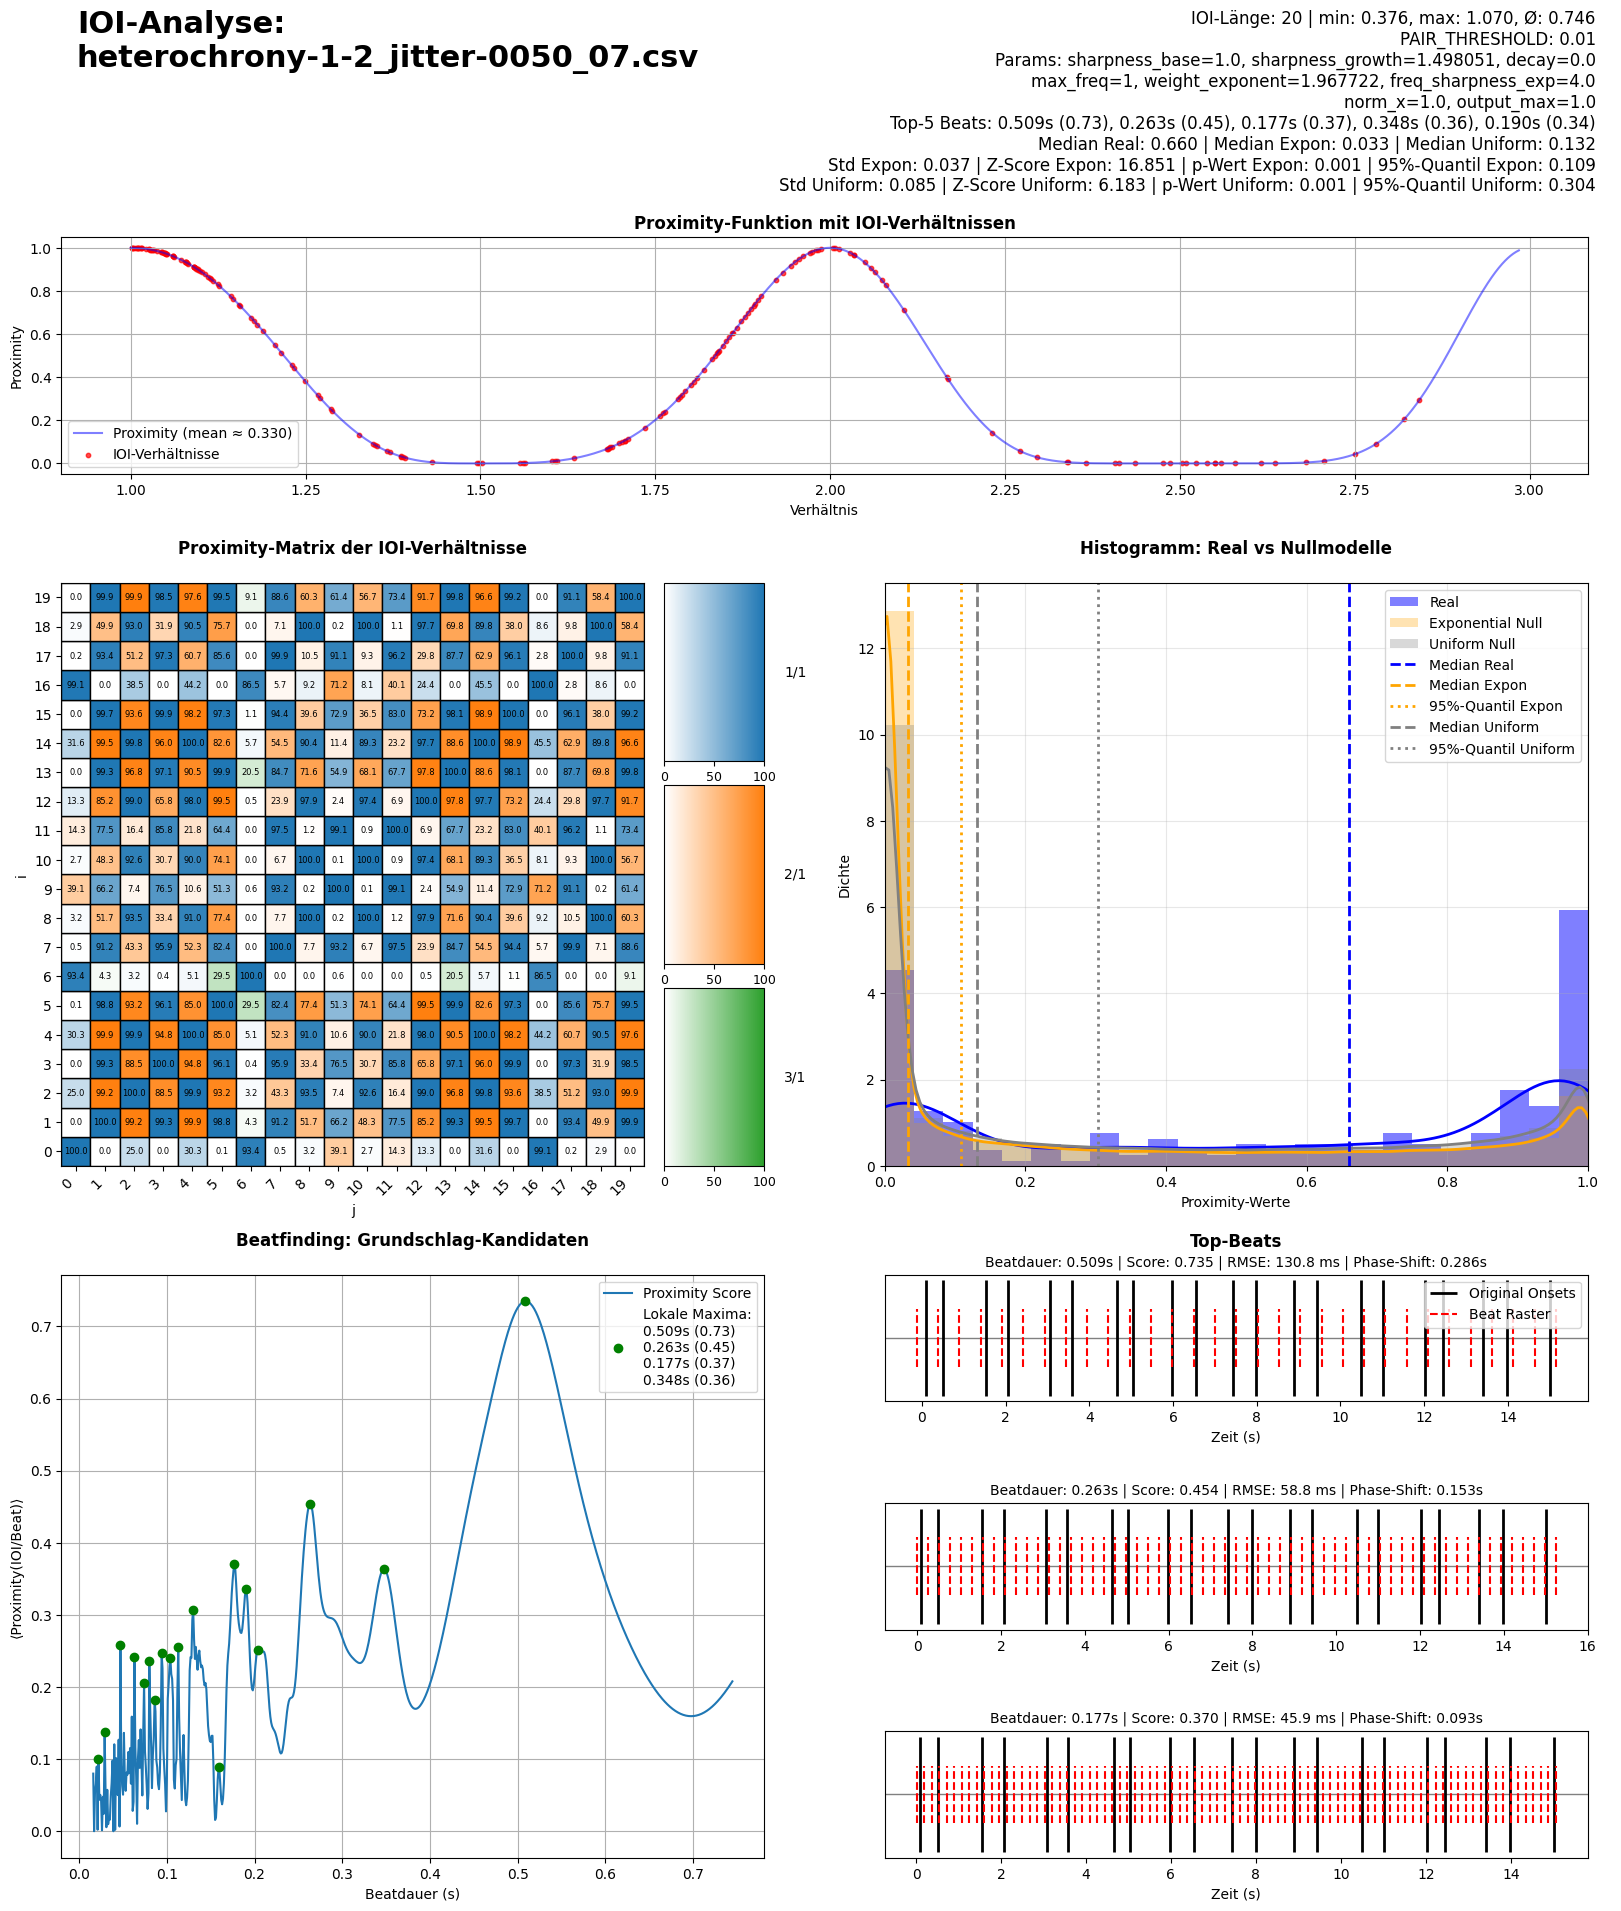

In [29]:
# gute Version

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpecFromSubplotSpec

# -----------------------------
# Figure vorbereiten
# -----------------------------
fig = plt.figure(figsize=(20, 24))

# Header-Zeile etwas höher machen
gs = gridspec.GridSpec(
    6, 2, figure=fig,
    width_ratios=[1,1],
    height_ratios=[0.5, 1, 1, 1, 1, 1],  # Header-Zeile größer
    hspace=0.5, wspace=0.3
)

ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")  # Achsen ausschalten

# Linker Titel oben links
ax_header.text(
    0.01, 1.0,
    f"IOI-Analyse:\n{filename}",
    transform=ax_header.transAxes,
    fontsize=22,
    fontweight='bold',
    va='top',
    ha='left'
)

# Rechter Zusatz oben rechts
info_lines = [
    f"IOI-Länge: {len(iois)} | min: {np.min(iois):.3f}, max: {np.max(iois):.3f}, Ø: {np.mean(iois):.3f}",
    f"PAIR_THRESHOLD: {PAIR_THRESHOLD}",
    f"Params: sharpness_base={params['sharpness_base']}, sharpness_growth={params['sharpness_growth']}, decay={params['decay']}",
    f"max_freq={params['max_freq']}, weight_exponent={params['weight_exponent']}, freq_sharpness_exp={params['freq_sharpness_exp']}",
    f"norm_x={params['norm_x']}, output_max={params['output_max']}",
    f"Top-5 Beats: " + ", ".join([f"{b:.3f}s ({s:.2f})" for b,s in local_maxima_top5[:5]]),
    f"Median Real: {results['results']['median_real']:.3f} | Median Expon: {results['results']['median_expon']:.3f} | Median Uniform: {results['results']['median_uniform']:.3f}",
    f"Std Expon: {results['results']['std_expon']:.3f} | Z-Score Expon: {results['results']['zscore_expon']:.3f} | p-Wert Expon: {results['results']['pval_expon']:.3f} | 95%-Quantil Expon: {results['results']['quant95_expon']:.3f}", 
    f"Std Uniform: {results['results']['std_uniform']:.3f} | Z-Score Uniform: {results['results']['zscore_uniform']:.3f} | p-Wert Uniform: {results['results']['pval_uniform']:.3f} | 95%-Quantil Uniform: {results['results']['quant95_uniform']:.3f}"
]

ax_header.text(
    0.99, 1.0,                       # oben rechts
    "\n".join(info_lines),
    transform=ax_header.transAxes,
    fontsize=12,
    va='top',
    ha='right'
)

# -----------------------------
# 1) Proximity-Funktion
# -----------------------------
ax1 = fig.add_subplot(gs[1, :])
x_range = np.linspace(max(1.0, df_pairs["ratio"].min()*0.95), df_pairs["ratio"].max()*1.05, 2000)
y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])
mean_prox = np.mean(y_curve)
ax1.plot(x_range, y_curve, label=f"Proximity (mean ≈ {mean_prox:.3f})", alpha=0.5, color="blue")
ax1.scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
ax1.set_title("Proximity-Funktion mit IOI-Verhältnissen", fontweight='bold')
ax1.set_xlabel("Verhältnis")
ax1.set_ylabel("Proximity")
ax1.grid(True)
ax1.legend()

# aktuelle Position auslesen
pos = ax1.get_position()

# gewünschte Breite setzen (z.B. 0.35 von der Originalbreite)
target_width = 0.7635

# neue Position: x0 bleibt gleich (linke Seite bleibt), Breite wird gestaucht
ax1.set_position([pos.x0, pos.y0, target_width, pos.height])

# -----------------------------
# Recurrence-Matrix + Histogramm rechts
# -----------------------------
ax2 = fig.add_subplot(gs[2:4, 0])
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")
n = len(iois)

for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]

    # Falls NaN -> weiß färben
    if np.isnan(val):
        color = (1, 1, 1, 1)
    else:
        color = cmap(val / 100)

    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
    ax2.add_patch(rect)

    # Werte in kleine Matrizen schreiben
    if n <= 20 and not np.isnan(val):
        ax2.text(
            j + 0.5, i + 0.5,
            f"{float(val):.1f}",  # jetzt sicher als float
            ha='center', va='center',
            fontsize=6, color="black"
        )

ax2.set_xlim(0, n)
ax2.set_ylim(0, n)
ax2.set_aspect('equal')
ax2.set_xticks(np.arange(n)+0.5)
ax2.set_yticks(np.arange(n)+0.5)
ax2.set_xticklabels(range(n), rotation=45, ha="right")
ax2.set_yticklabels(range(n))
ax2.set_xlabel("j")
ax2.set_ylabel("i")
ax2.set_title("Proximity-Matrix der IOI-Verhältnisse\n", fontweight='bold')

# aktuelle Position auslesen
pos = ax2.get_position()

# leicht nach links verschieben (x0 und x1 kleiner machen)
shift = 0.0227   # Feinjustieren!
ax2.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

# neue Position nach dem Verschieben holen
pos = ax2.get_position()

# Farbskalen rechts der Matrix
unique_labels = sorted(set(all_pairs_df["peak_label"]))
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]

cbar_width = 0.05
spacing = 0.01
n_labels = len(legend_labels)
bar_height = (pos.height - (n_labels-1)*spacing) / n_labels

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar_y = pos.y0 + pos.height - (idx+1)*bar_height - idx*spacing
    cbar_ax = fig.add_axes([pos.x1 + 0.01, cbar_y, cbar_width, bar_height])
    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        orientation="horizontal"
    )
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)
    fig.text(pos.x1 + 0.07, cbar_y + bar_height/2, label, va='center', fontsize=10)

# Histogramm rechts
ax3 = fig.add_subplot(gs[2:4, 1])
colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
bin_edges = np.linspace(0, 1, 25)
ax3.hist(results["proximity_real"], bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
ax3.hist(results["proximity_expon_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Exponential Null")
ax3.hist(results["proximity_uniform_all"], bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Uniform Null")
sns.kdeplot(results["proximity_real"], bw_adjust=0.5, color=colors["Real"], linewidth=2, ax=ax3)
sns.kdeplot(results["proximity_expon_all"], bw_adjust=0.5, color=colors["Expon"], linewidth=2, ax=ax3)
sns.kdeplot(results["proximity_uniform_all"], bw_adjust=0.5, color=colors["Uniform"], linewidth=2, ax=ax3)
ax3.axvline(results["results"]["median_real"], color=colors["Real"], linestyle="--", linewidth=2, label="Median Real")
ax3.axvline(results["results"]["median_expon"], color=colors["Expon"], linestyle="--", linewidth=2, label="Median Expon")
ax3.axvline(results["results"]["quant95_expon"], color=colors["Expon"], linestyle=":", linewidth=2, label="95%-Quantil Expon")
ax3.axvline(results["results"]["median_uniform"], color=colors["Uniform"], linestyle="--", linewidth=2, label="Median Uniform")
ax3.axvline(results["results"]["quant95_uniform"], color=colors["Uniform"], linestyle=":", linewidth=2, label="95%-Quantil Uniform")
ax3.set_xlim(0, 1)
ax3.set_xlabel("Proximity-Werte")
ax3.set_ylabel("Dichte")
ax3.set_title("Histogramm: Real vs Nullmodelle\n", fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

target_width = 0.3515294117647057  # gemessene Breite der Matrix + Skala

pos_other = ax3.get_position()
ax3.set_position([pos_other.x0, pos_other.y0, target_width, pos_other.height])

# aktuelle Position auslesen
pos = ax3.get_position()

# leicht nach links verschieben (x0 und x1 kleiner machen)
shift_right = 0.0263   # Feinjustieren!
ax3.set_position([pos.x0 - shift_right, pos.y0, pos.width, pos.height])

# neue Position nach dem Verschieben holen
pos = ax3.get_position()

# -----------------------------
# Unterer Bereich: Beat-Kandidaten + Top-Beats
# -----------------------------
# Grundschlag-Plot
ax4 = fig.add_subplot(gs[4:6, 0])
ax4.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    ax4.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5[:4]]
ax4.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
ax4.set_xlabel("Beatdauer (s)")
ax4.set_ylabel("⟨Proximity(IOI/Beat)⟩")
ax4.set_title("Beatfinding: Grundschlag-Kandidaten\n", fontweight='bold')
ax4.grid(True)
ax4.legend()

target_width = 0.3515294117647057  # von oben gemessen

# Linke Seite (Beat-Kandidaten)
pos_left = ax4.get_position()
ax4.set_position([pos_left.x0, pos_left.y0, target_width, pos_left.height])

# Rechte Spalte: Top-Beats
height_ratios = [0.9, 0.9, 0.9]
right_gs = GridSpecFromSubplotSpec(
    3, 1, subplot_spec=gs[4:6, 1],
    hspace=0.8, height_ratios=height_ratios
)

n_top_display = min(3, len(local_maxima_top5))
ax_tops = []  # hier speichern wir die Subplots
for idx in range(n_top_display):
    ax_top = fig.add_subplot(right_gs[idx])
    ax_tops.append(ax_top)

    beat, score = local_maxima_top5[idx]
    best_shift, best_rmse, best_beats = compute_beat_rmse(onsets, beat)

    ax_top.axhline(0, color='gray', linewidth=1)
    ax_top.vlines(onsets, -0.2, 0.2, color='black', linewidth=2,
                  label='Original Onsets' if idx==0 else "")
    ax_top.vlines(best_beats, -0.1, 0.1, color='red', linestyle='--',
                  label='Beat Raster' if idx==0 else "")

    title = (f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | "
             f"RMSE: {best_rmse*1000:.1f} ms | Phase-Shift: {best_shift:.3f}s")
    ax_top.set_title(title, fontsize=10)
    ax_top.set_yticks([])
    ax_top.set_xlabel("Zeit (s)")
    if idx == 0:
        ax_top.legend(loc='upper right')

# --- Breite angleichen (nach dem Zeichnen!) ---
for ax_top in ax_tops:
    pos = ax_top.get_position()
    ax_top.set_position([pos.x0 - shift_right, pos.y0, target_width, pos.height])

# Position der rechten Spalte über die Achsen bestimmen
top_ax_pos = ax_tops[0].get_position()       # ganz oben
bottom_ax_pos = ax_tops[-1].get_position()   # ganz unten

# Bounding Box für die Spalte
x0 = top_ax_pos.x0
x1 = top_ax_pos.x1
y0 = bottom_ax_pos.y0
y1 = top_ax_pos.y1

# --- Gemeinsamer Titel für die ganze Spalte ---
# Statt y1 + 0.02 -> etwas weiter unten, wie ax.set_title()
fig.text(
    (x0 + x1)/2,
    y1 + 0.01,    # etwas tiefer, damit es wie ein normaler Plot-Titel wirkt
    "Top-Beats",
    ha="center", va="bottom",
    fontsize=12, fontweight="bold"
)

plt.tight_layout